In [7]:
import numpy as np
import os
import pandas as pd
import yfinance as yf
import time
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")
spycount = 0
sbuxcount = 0
spyee = 0
sbuxee = 0
starbucks = pd.read_csv("sbux.csv")
spy = pd.read_csv("spy.csv")
starbucks.drop(index=0, inplace=True)
spy.drop(index=0, inplace=True)

sbux_return = starbucks['Return'].values
spy_return = spy['Return'].values

print(sbux_return)
m, c = np.polyfit(sbux_return, spy_return, 1)
print(m,c)


spycount = np.sum(spy_return > 0)
sbuxcount = np.sum(sbux_return > 0)

starbucks_mean = starbucks['Return'].mean()
starbucks_std = starbucks['Return'].std()
spy_mean = spy['Return'].mean()
spy_std = spy['Return'].std()

spyee = np.sum(spy_return > spy_mean + 2 * spy_std)
sbuxee = np.sum(sbux_return > starbucks_mean + 2 * starbucks_std)

print(spycount, sbuxcount)
print(spyee, sbuxee)






[ 0.          0.00329785  0.00725065 ...  0.00603057  0.00575929
 -0.00373968]
0.2991547981719748 0.0005708078588842899
686 623
26 25


Rank 1: I -> 15
Rank 2: the -> 15
Rank 3: a -> 13
Rank 4: of -> 13
Rank 5: to -> 10
Rank 6: and -> 7
Rank 7: that -> 7
Rank 8: in -> 5
Rank 9: was -> 5
Rank 10: is -> 4
Rank 11: more -> 3
Rank 12: this -> 3
Rank 13: it -> 3
Rank 14: or -> 3
Rank 15: an -> 3
Rank 16: at -> 3
Rank 17: my -> 3
Rank 18: but -> 2
Rank 19: he -> 2
Rank 20: has -> 2
Rank 21: me -> 2
Rank 22: when -> 2
Rank 23: came -> 2
Rank 24: about -> 2
Rank 25: were -> 2
Rank 26: have -> 2
Rank 27: by -> 2
Rank 28: some -> 2
Rank 29: intimate -> 2
Rank 30: on -> 2
Rank 31: which -> 2
Rank 32: something -> 2
Rank 33: if -> 2
Rank 34: as -> 2
Rank 35: snobbishly -> 2
Rank 36: after -> 2
Rank 37: be -> 2
Rank 38: founded -> 2
Rank 39: from -> 2
Rank 40: wanted -> 2
Rank 41: who -> 2
Rank 42: He -> 1
Rank 43: didn't -> 1
Rank 44: say -> 1
Rank 45: any -> 1
Rank 46: we've -> 1
Rank 47: always -> 1
Rank 48: been -> 1
Rank 49: unusually -> 1
Rank 50: communicative -> 1
Rank 51: reserved -> 1
Rank 52: way, -> 1
Rank 53: understoo

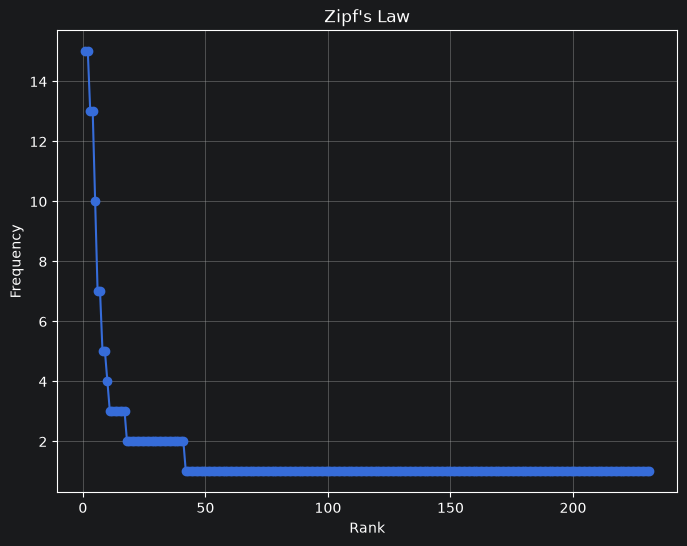

In [5]:
text = "He didn't say any more but we've always been unusually communicative in a reserved way, and I understood that he meant a great deal more than that. In consequence I'm inclined to reserve all judgments, a habit that has opened up many curious natures to me and also made me the victim of not a few veteran bores. The abnormal mind is quick to detect and attach itself to this quality when it appears in a normal person, and so it came about that in college I was unjustly accused of being a politician, because I was privy to the secret griefs of wild, unknown men. Most of the confidences were unsought—frequently I have feigned sleep, preoccupation, or a hostile levity when I realized by some unmistakable sign that an intimate revelation was quivering on the horizon—for the intimate revelations of young men or at least the terms in which they express them are usually plagiaristic and marred by obvious suppressions. Reserving judgments is a matter of infinite hope. I am still a little afraid of missing something if I forget that, as my father snobbishly suggested, and I snobbishly repeat, a sense of the fundamental decencies is parcelled out unequally at birth.And, after boasting this way of my tolerance, I come to the admission that it has a limit. Conduct may be founded on the hard rock or the wet marshes but after a certain point I don't care what it's founded on. When I came back from the East last autumn I felt that I wanted the world to be in uniform and at a sort of moral attention forever; I wanted no more riotous excursions with privileged glimpses into the human heart. Only Gatsby, the man who gives his name to this book, was exempt from my reaction—Gatsby who represented everything for which I have an unaffected scorn. If personality is an unbroken series of successful gestures, then there was something gorgeous about him, some heightened sensitivity to the promises of life, as if he were related to one of those intricate machines that register earthquakes ten thousand miles away."

result = text.split(' ')
dictionary = {}
for i in result:
    dictionary[i] = dictionary.get(i,0) + 1
dictionary = dict(sorted(dictionary.items(), key=lambda item: -item[1]))


for rank, (word, freq) in enumerate(dictionary.items(), start=1):
    print(f"Rank {rank}: {word} -> {freq}")

import matplotlib.pyplot as plt
ranks = list(range(1, len(dictionary) + 1))
frequencies = list(dictionary.values())
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(ranks, frequencies, marker='o')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")
plt.grid(True)
plt.show()

In [12]:
starbucks = pd.read_csv("sbux.csv")
starbucks.drop(index = 0, inplace = True)
Short = starbucks["Short_MA"]
Long = starbucks["Long_MA"]
price = starbucks["Close"]
money = 400
num_stocks = 0

for i in range(0, len(starbucks)):
    if money >= float(price.iloc[i]) and Short.iloc[i] > Long.iloc[i]:
        money -= float(price.iloc[i])
        num_stocks += 1

print(num_stocks)

if num_stocks > 0:
    for i in range(0, len(starbucks)):
        if Short.iloc[i] < Long.iloc[i]:
            money += float(price.iloc[i])
            num_stocks -= 1
print(num_stocks)
print(money)


4
-640
55410.09


,Date,Year,Month,Day,Weekday,Week_Number,Year_Week,Open,High,Low,Close,Volume,Return,Short_MA,Long_MA
1,2021-01-04,2021.0,1.0,4.0,Monday,1.0,2021-01,95.02,95.1,90.15,91.0,8041500,0.000000,91.000000,91.0000
2,2021-01-05,2021.0,1.0,5.0,Tuesday,1.0,2021-01,90.84,92.02,90.73,91.3,5721900,0.003298,91.150000,91.1500
3,2021-01-06,2021.0,1.0,6.0,Wednesday,1.0,2021-01,90.9,92.86,90.83,91.96,5017200,0.007251,91.420000,91.4200
4,2021-01-07,2021.0,1.0,7.0,Thursday,1.0,2021-01,92.22,92.36,90.86,91.22,5057000,-0.008062,91.370000,91.3700
5,2021-01-08,2021.0,1.0,8.0,Friday,1.0,2021-01,91.67,93.34,91.28,93.27,5869700,0.022448,91.750000,91.7500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,2025-12-23,2025.0,12.0,23.0,Tuesday,51.0,2025-51,84.97,85.09,82.36,82.84,9511300,-0.026807,84.190714,83.3902
1251,2025-12-24,2025.0,12.0,24.0,Wednesday,51.0,2025-51,82.82,83.59,82.45,83.54,3462700,0.008466,84.160714,83.4692
1252,2025-12-26,2025.0,12.0,26.0,Friday,51.0,2025-51,83.55,84.12,83.39,84.04,5046200,0.006031,84.157857,83.5248
1253,2025-12-29,2025.0,12.0,29.0,Monday,52.0,2025-52,84.08,85.73,83.94,84.53,5352400,0.005759,84.310714,83.5612
